In [ ]:
# IMPORT BLOCK

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(
    "/Users/pater32/Documents/GitHub/sage/GWRecoil/output/sage-plot"
)

import sage_loader
from sage_loader import get_params, load_snapshot, load_variable, load_all_snapshots, load_variable_all_snapshots
from snapshot_redshift_mapper import SnapshotRedshiftMapper as z_mapper

In [7]:
## ARRAY REALIZATIONS
param_file = "/Users/pater32/Documents/GitHub/sage/GWRecoil/input/tng50.par"
galaxies_z0_1, volume_1, metadata_1 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1')
galaxies_z0_2, volume_2, metadata_2 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run2')
galaxies_z0_3, volume_3, metadata_3 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run3')
galaxies_z0_4, volume_4, metadata_4 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run4')
galaxies_z0_5, volume_5, metadata_5 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run5')
galaxies_z0_6, volume_6, metadata_6 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run6')
galaxies_z0_7, volume_7, metadata_7 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run7')
galaxies_z0_8, volume_8, metadata_8 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run8')
galaxies_z0_9, volume_9, metadata_9 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run9')
galaxies_z0_10, volume_10, metadata_10 = load_snapshot(param_file, 99, '/Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10')

## REDSHIFT MAPPER FUNCTION 
params = get_params(param_file)
mapper = z_mapper(params=params)

## HELPER FUNCTIONS
def safe_div(numerator, denominator):
    if denominator > 0.0:
        return numerator/denominator
    else:
        return 0.0
    
def safe_log10(value):
    if value > 0:
        return np.log10(value)
    else:
        return np.nan

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run1/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run2/model_z0.000
Input files contain: 15618 trees, 22283 galaxies.
Reading 22283 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run2/model_z0.000_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pate

In [8]:
print(mapper.get_redshift(75))

0.34999999952750005


In [9]:
## APPEND ALL GALAXY ARRAYS
galaxies_z0 = [
    galaxies_z0_1,
    galaxies_z0_2,
    galaxies_z0_3,
    galaxies_z0_4,
    galaxies_z0_5,
    galaxies_z0_6,
    galaxies_z0_7,
    galaxies_z0_8,
    galaxies_z0_9,
    galaxies_z0_10,
]

hubble_h = metadata_1['hubble_h']

Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z20.050
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z20.050_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z14.990
Input files contain: 15618 trees, 0 galaxies.
Reading 0 galaxies from file: /Users/pater32/Documents/GitHub/sage/GWRecoil/output/results/illustristng/tng50_4/run10/model_z14.990_0
Loaded 100 redshift values from /Users/pater32/Documents/GitHub/sage/mergertrees/illustristng/illustristng.a_list
Reading galaxy data from /Users/pater32/Docu

Text(0, 0.5, 'Cold Gas / Total Gas')

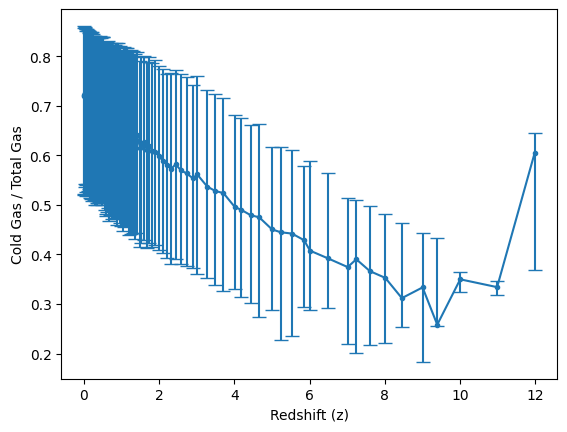

In [10]:
## GAS FRACTION GROWTH PLOTS

cold_gas_percentages = {}
for snap in range(100):
    galaxies, volume, metadata = load_snapshot(param_file, snap)
    redshift = metadata['redshift']
    array_length = len(galaxies)

    for i in range(array_length):
        if (galaxies.ColdGas[i] > 0) & (galaxies.HotGas[i] > 0):
            cold_gas = galaxies.ColdGas[i]
            hot_gas = galaxies.HotGas[i]
            cold_gas_percentage = cold_gas/(cold_gas + hot_gas)

        if redshift not in cold_gas_percentages:
            cold_gas_percentages[redshift] = {
                'cold_gas_perc': []
            }
        
        cold_gas_percentages[redshift]['cold_gas_perc'].append(cold_gas_percentage)

redshifts = []
cold_gas_medpercs = []
cold_gas_25percs = []
cold_gas_75percs = []
for redshift in cold_gas_percentages: 
    cold_gas_percs = cold_gas_percentages[redshift]['cold_gas_perc']
    cold_gas_medperc = np.median(cold_gas_percs)
    cold_gas_25perc = np.percentile(cold_gas_percs, 25)
    cold_gas_75perc = np.percentile(cold_gas_percs, 75)

    cold_gas_medpercs.append(cold_gas_medperc)
    cold_gas_25percs.append(cold_gas_25perc)
    cold_gas_75percs.append(cold_gas_75perc)
    redshifts.append(redshift)

med = np.array(cold_gas_medpercs)
p25 = np.array(cold_gas_25percs)
p75 = np.array(cold_gas_75percs)
errors = [med - p25, p75 - med]
plt.errorbar(redshifts, cold_gas_medpercs, marker = 'o', markersize = 3, yerr=errors, capsize=5)
# plt.plot(redshifts, cold_gas_medpercs, marker='o', markersize=1)
plt.xlabel('Redshift (z)')
plt.ylabel('Cold Gas / Total Gas')


        
